## ML Roadmap (Industry Approach)

1. Understand the Business Problem
        ↓
2. Load Data
        ↓
3. Data Understanding (EDA)
        ↓
4. Data Cleaning
        ↓
5. Data Preprocessing
        ↓
6. Feature Engineering
        ↓
7. Feature Selection
        ↓
8. Train-Test Split
        ↓
9. Model Selection
        ↓
10. Model Training
        ↓
11. Model Evaluation
        ↓
12. Hyperparameter Tuning
        ↓
13. Model Saving
        ↓
14. Deployment

## Phase 1: Data Understanding

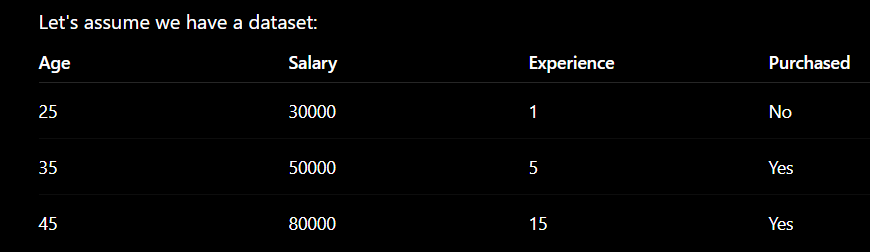

In [207]:
# Load the Data
import pandas as pd
import numpy as np

df = pd.read_csv('data.csv')

df.head()

,Age,Salary,Experience,Gender,City,Purchased
0,25,50000,1,Male,Bangalore,No
1,35,50000,5,Female,Delhi,Yes
2,45,80000,15,Male,Mumbai,Yes
3,28,35000,2,Female,Bangalore,No
4,32,45000,4,Male,Delhi,Yes


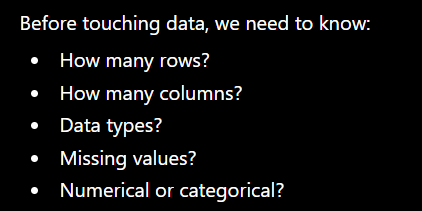

In [209]:
df.shape

(10, 6)

In [210]:
df.columns

Index(['Age', 'Salary', 'Experience', 'Gender', 'City', 'Purchased'], dtype='object')

In [211]:
df.describe()

,Age,Salary,Experience
count,10.000000,1.000000e+01,10.000000
mean,34.900000,7.480000e+05,7.200000
std,8.279157,2.196810e+06,6.442912
min,25.000000,3.200000e+04,1.000000
25%,28.250000,3.975000e+04,2.250000
50%,33.500000,5.000000e+04,4.500000
75%,39.500000,7.500000e+04,11.000000
max,50.000000,7.000000e+06,20.000000


In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Age         10 non-null     int64 
 1   Salary      10 non-null     int64 
 2   Experience  10 non-null     int64 
 3   Gender      10 non-null     object
 4   City        10 non-null     object
 5   Purchased   10 non-null     object
dtypes: int64(3), object(3)
memory usage: 612.0+ bytes


In [213]:
# Check for null

df.isna().sum()

Age           0
Salary        0
Experience    0
Gender        0
City          0
Purchased     0
dtype: int64

## Phase 2 : Null Value Treatment

If there are any missing values 

We use Mean , Median and Mode for filling the null values

Example 1 :

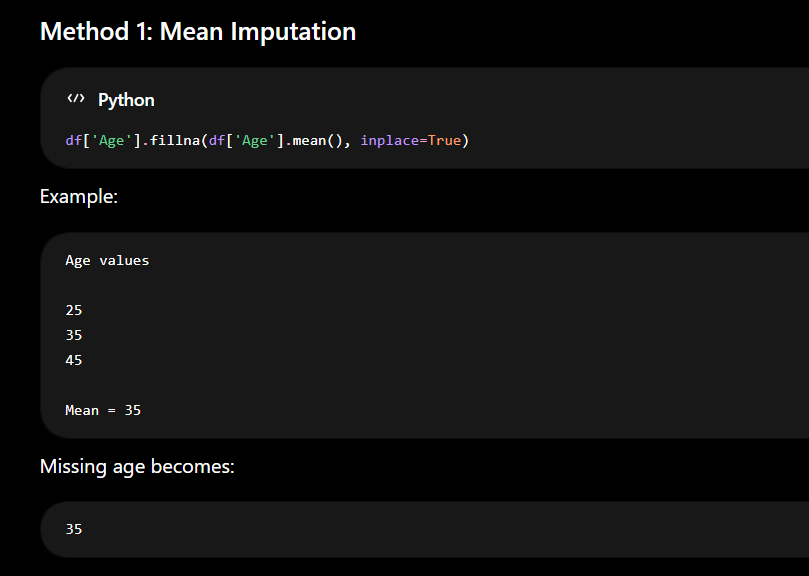

Example 2 :

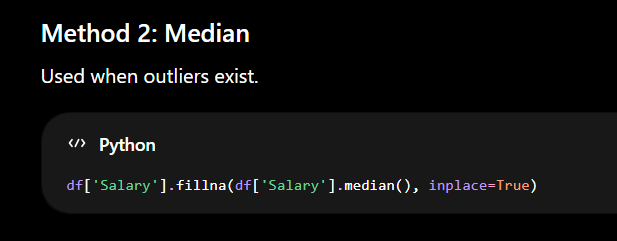

Example 3 :

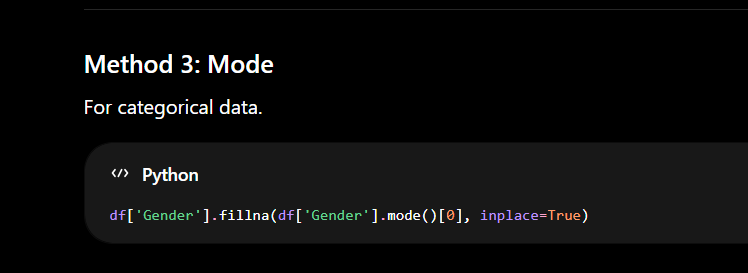

## Phase 3: Memory Optimization

In [217]:
# Let's find the present memory size of the dataframe

start_memory = df.memory_usage(deep=True).sum()/1024
print(f"Memory : {start_memory:.2f} Kb")

Memory : 1.94 Kb


In [218]:
# let's optimize the memory
import numpy as np

for col in df.columns:
    col_type = df[col].dtype

    if pd.api.types.is_integer_dtype(col_type):
        cmin = df[col].min()
        cmax = df[col].max()

        if cmin >= np.iinfo(np.int8).min and cmax <= np.iinfo(np.int8).max:
            df[col] = df[col].astype(np.int8)
        elif cmin >= np.iinfo(np.int16).min and cmax <= np.iinfo(np.int16).max:
            df[col] = df[col].astype(np.int16)
        elif cmin >= np.iinfo(np.int32).min and cmax <= np.iinfo(np.int32).max:
            df[col] = df[col].astype(np.int32)
        else :
            df[col] = df[col].astype(np.int64)

    if pd.api.types.is_float_dtype(col_type):
        cmin = df[col].min
        cmax = df[col].max

        if cmin >= np.finfo(np.float16).min and cmax <= np.finfo(np.float16).max:
            df[col] = df[col].astype(np.float16)
        elif cmin >= np.finfo(np.float32).min and cmax <= np.finfo(np.float32).max:
            df[col] = df[col].astype(np.float32)
        else :
            df[col] = df[col].astype(np.float64)

end_memory = df.memory_usage(deep=True).sum()/1024

per = (end_memory/start_memory)*100

print(f"Memory after Optimization : {end_memory:.2f} Kb \nMemory Usage Reduced by {per:.2f} %")

Memory after Optimization : 1.76 Kb 
Memory Usage Reduced by 90.94 %


## Phase 4: Outlier Treatment

<Axes: ylabel='Salary'>

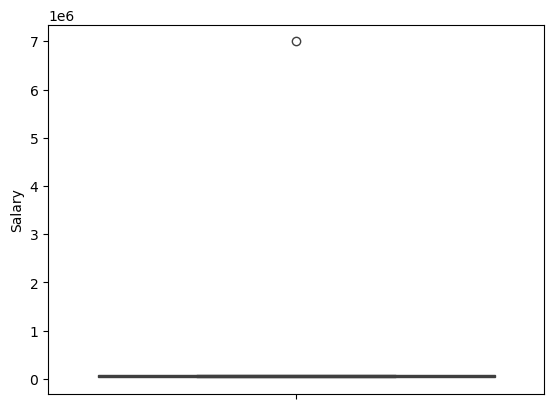

In [220]:
import seaborn as sns

# Before Removing Outliers

sns.boxplot(df['Salary'])

In [221]:
df['Salary']

0      50000
1      50000
2      80000
3      35000
4      45000
5    7000000
6      38000
7      60000
8      90000
9      32000
Name: Salary, dtype: int32

In [222]:
# 5    7000000 is an outlier

# Remove using IQR

Q1 = df['Salary'].quantile(0.25)
Q3 = df['Salary'].quantile(0.75)

IQR = Q3-Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

df = df[(df['Salary'] >= lower) & (df['Salary'] <= upper)]

<Axes: ylabel='Salary'>

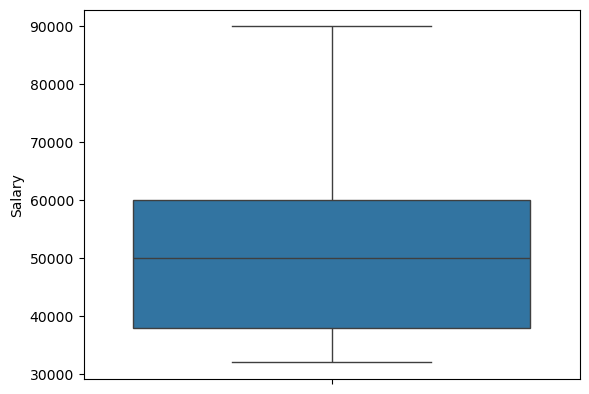

In [223]:
sns.boxplot(df['Salary'])

## Phase 5: Encoding

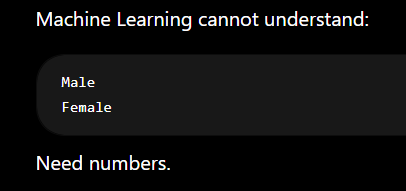

In [226]:
df['Gender']

0      Male
1    Female
2      Male
3    Female
4      Male
6      Male
7    Female
8      Male
9    Female
Name: Gender, dtype: object

In [227]:
# Label Encoding

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df['Gender'] = le.fit_transform(df['Gender'])

In [228]:
df['Gender']

0    1
1    0
2    1
3    0
4    1
6    1
7    0
8    1
9    0
Name: Gender, dtype: int32

In [229]:
df['Purchased'] = le.fit_transform(df['Purchased'])

In [230]:
df['Purchased']

0    0
1    1
2    1
3    0
4    1
6    0
7    1
8    1
9    0
Name: Purchased, dtype: int32

In [231]:
df['City']

0    Bangalore
1        Delhi
2       Mumbai
3    Bangalore
4        Delhi
6    Bangalore
7        Delhi
8       Mumbai
9    Bangalore
Name: City, dtype: object

In [232]:
# One Hot Encoding
encoded = pd.get_dummies(df,columns=['City'],dtype='int')

In [233]:
encoded

,Age,Salary,Experience,Gender,Purchased,City_Bangalore,City_Delhi,City_Mumbai
0,25,50000,1,1,0,1,0,0
1,35,50000,5,0,1,0,1,0
2,45,80000,15,1,1,0,0,1
3,28,35000,2,0,0,1,0,0
4,32,45000,4,1,1,0,1,0
6,29,38000,3,1,0,1,0,0
7,38,60000,8,0,1,0,1,0
8,50,90000,20,1,1,0,0,1
9,27,32000,2,0,0,1,0,0


## Phase 6: Feature Scaling

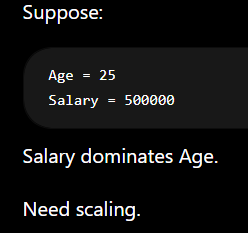

In [290]:
# Lets split the data to features and taregt

X = encoded.drop('Purchased',axis=1)
y = encoded['Purchased']

In [237]:
print(X.head())

   Age  Salary  Experience  Gender  City_Bangalore  City_Delhi  City_Mumbai
0   25   50000           1       1               1           0            0
1   35   50000           5       0               0           1            0
2   45   80000          15       1               0           0            1
3   28   35000           2       0               1           0            0
4   32   45000           4       1               0           1            0


In [239]:
# X_scaled

In [298]:
# Split data to train and test

from sklearn.model_selection import train_test_split

X_train,X_test,Y_train,Y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [302]:
print(X_train.shape , X_test.shape)

(7, 7) (2, 7)


In [284]:
print(X_test.shape)

(7,)


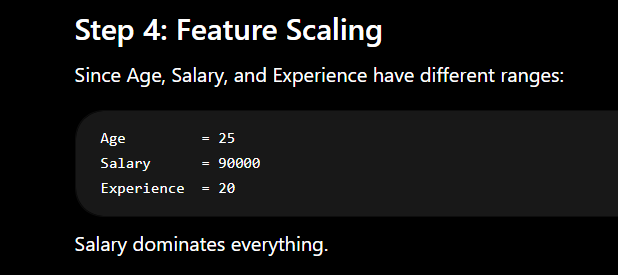

In [304]:
X_test.head()

,Age,Salary,Experience,Gender,City_Bangalore,City_Delhi,City_Mumbai
8,50,90000,20,1,0,0,1
1,35,50000,5,0,0,1,0


In [306]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [308]:
print(X_train_scaled)

[[-0.45523273 -0.67761704 -0.43495884  0.8660254   0.8660254  -0.63245553
  -0.40824829]
 [-1.06220971  0.09156987 -0.86991767  0.8660254   0.8660254  -0.63245553
  -0.40824829]
 [-0.75872122 -1.06221049 -0.65243825 -1.15470054  0.8660254  -0.63245553
  -0.40824829]
 [ 1.97267518  2.01453714  2.17479418  0.8660254  -1.15470054 -0.63245553
   2.44948974]
 [ 0.         -0.22892467 -0.21747942  0.8660254  -1.15470054  1.58113883
  -0.40824829]
 [-0.60697698 -0.86991376 -0.65243825 -1.15470054  0.8660254  -0.63245553
  -0.40824829]
 [ 0.91046547  0.73255896  0.65243825 -1.15470054 -1.15470054  1.58113883
  -0.40824829]]


In [310]:
# Let's convert X_train_scaled, and test to DataFrames

X_train_scaled = pd.DataFrame(X_train_scaled, columns = X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns = X_test.columns)

In [312]:
X_train_scaled.head()

,Age,Salary,Experience,Gender,City_Bangalore,City_Delhi,City_Mumbai
0,-0.455233,-0.677617,-0.434959,0.866025,0.866025,-0.632456,-0.408248
1,-1.062210,0.091570,-0.869918,0.866025,0.866025,-0.632456,-0.408248
2,-0.758721,-1.062210,-0.652438,-1.154701,0.866025,-0.632456,-0.408248
3,1.972675,2.014537,2.174794,0.866025,-1.154701,-0.632456,2.449490
4,0.000000,-0.228925,-0.217479,0.866025,-1.154701,1.581139,-0.408248


## Phase 7 : Train Your First Model

In [315]:
# Since it is a classification problem, let's use logisti regression

In [317]:
from sklearn.linear_model import LogisticRegression

reg = LogisticRegression()

reg.fit(X_train_scaled,Y_train)

LogisticRegression()

## Phase 8: Prediction

In [323]:
y_pred = reg.predict(X_test_scaled)

print(y_pred)

[1 1]


## Phase 9: Evaluate

In [325]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(Y_test,y_pred)

print(f"Accuracy : {accuracy}")

Accuracy : 1.0


In [327]:
# Since your dataset has only 9 records, don't worry if the accuracy jumps around. The goal is to learn the workflow.